<a href="https://colab.research.google.com/github/Neeraj-P-Raju/AIML-internship/blob/main/weather_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1490/2028236310.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_Dresden.loc[:, 'BBQ'] = df_Dresden['BBQ'].map({True:1, False:0});


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       574
           1       0.93      0.90      0.92       157

    accuracy                           0.96       731
   macro avg       0.95      0.94      0.95       731
weighted avg       0.96      0.96      0.96       731



0.9644322845417237

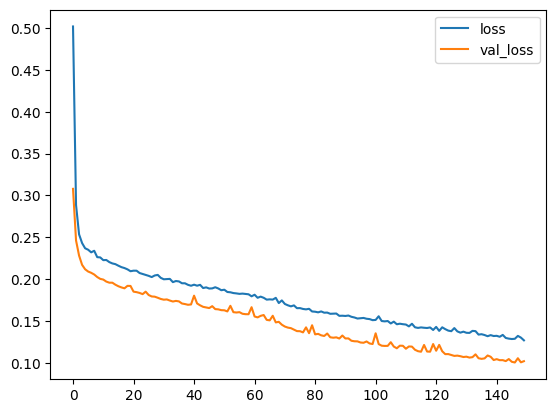

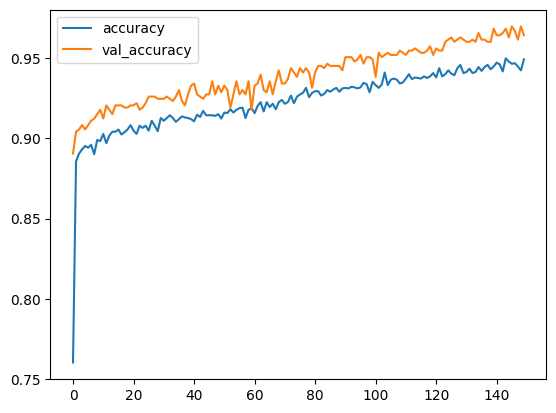

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, Reshape, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

df = pd.read_csv('weather_prediction_dataset.csv')
df_bbq = pd.read_csv('weather_prediction_bbq_labels.csv')
df.head(6)
df_bbq.head(6)
len(df_bbq.columns), df_bbq.columns
df.columns
df.columns[30:41]
df_Dresden = df[['DATE', 'DRESDEN_cloud_cover', 'DRESDEN_wind_speed', 'DRESDEN_wind_gust',
       'DRESDEN_humidity', 'DRESDEN_global_radiation', 'DRESDEN_precipitation',
       'DRESDEN_sunshine', 'DRESDEN_temp_mean', 'DRESDEN_temp_min',
       'DRESDEN_temp_max']]
# Merging df_Dresden with df_bbq on 'DATE' to correctly align the 'BBQ' column
df_Dresden = pd.merge(df_Dresden, df_bbq[['DATE', 'DRESDEN_BBQ_weather']], on='DATE', how='left')
df_Dresden = df_Dresden.rename(columns={'DRESDEN_BBQ_weather': 'BBQ'})
df_Dresden.loc[:, 'BBQ'] = df_Dresden['BBQ'].map({True:1, False:0});
df_Dresden.head()

X = df_Dresden.drop(['DATE','BBQ'], axis = 1)
y = df_Dresden['BBQ']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 28)

model_2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Reshape((X_train.shape[1], 1)),
    Conv1D(filters=10, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(1, activation = 'sigmoid')
])
model_2.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy'])
model_2.fit(x=X_train,
          y=y_train,
          epochs=150,
          validation_data=(X_test, y_test), verbose=0
          )
model2_loss_acc = pd.DataFrame(model_2.history.history)
model2_loss_acc[['loss', 'val_loss']].plot()
model2_loss_acc[['accuracy', 'val_accuracy']].plot()
pred_2 = np.round(model_2.predict(X_test))
print(classification_report(y_test,pred_2))
cnn_acc = accuracy_score(y_test, pred_2)
cnn_acc

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       574
           1       0.90      0.84      0.87       157

    accuracy                           0.95       731
   macro avg       0.93      0.91      0.92       731
weighted avg       0.94      0.95      0.94       731



((2923, 10), (731, 10))

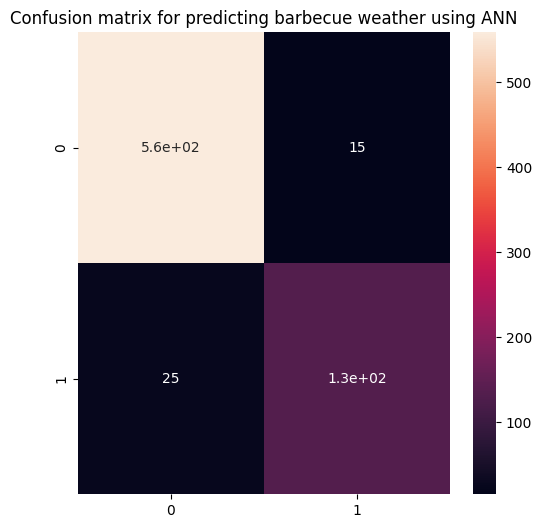

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Conv1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler
X = df_Dresden.drop(['DATE','BBQ'], axis = 1)
y = df_Dresden['BBQ']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 28)
len(X_train), len(X_test)

# Scale the input features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
        Dense(X_train_scaled.shape[1], activation="relu"),
        Dense(X_train_scaled.shape[1]//2, activation="relu"),
        Dense(1, activation = 'sigmoid'),
    ])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics = ['accuracy'])
model.fit(x=X_train_scaled, # Use scaled data for training
          y=y_train,
          epochs=150,
          validation_data=(X_test_scaled, y_test), verbose=0 # Use scaled data for validation
          )
predictions = np.round(model.predict(X_test_scaled)) # Use scaled data for prediction
print(classification_report(y_test,predictions))
ann_acc = accuracy_score(y_test, predictions)
ann_acc
plt.figure(figsize = (6,6))
sns.heatmap(confusion_matrix(y_test, predictions), annot = True)
plt.title('Confusion matrix for predicting barbecue weather using ANN');
from tensorflow.keras.layers import Conv1D, Flatten, Reshape
X_train.shape, X_test.shape

In [17]:
model.get_weights()


[array([[  0.33496675,   0.6204132 ,  -0.3215714 ,  -0.24197723,
           0.6370522 ,   0.3080954 ,  -0.20894897,  -0.49786437,
           0.2913127 ,   0.33871064],
        [  0.7717321 ,   0.8853617 ,  -0.5224951 ,  -0.3688851 ,
           0.04319692,  -0.2830965 ,  -0.29806852,   0.02739078,
           0.54530036,  -0.266102  ],
        [ -0.2328091 ,  -0.27065468,  -0.51479846,   0.2981708 ,
           0.5461506 ,   0.4511284 ,  -0.13053644,   0.09905314,
          -1.0862647 ,   0.9126435 ],
        [  0.02979647,  -0.15769489,  -0.115343  ,  -0.21418713,
          -0.1863561 ,   0.36799368,  -0.4801783 ,  -0.4995389 ,
           0.4503404 ,   0.40067288],
        [  0.6480485 ,   0.12713154,  -0.0828215 ,  -0.12231215,
          -0.30764222,   0.17159948,  -0.45938972,  -0.42420128,
           0.6214401 ,   0.41365212],
        [-10.804869  , -10.443017  ,  -0.4038761 ,   0.4936757 ,
          11.031517  ,   0.46625477,   0.18217039,  -0.31183046,
         -10.537775  ,  11.144

In [19]:
model_2.get_weights()


[array([[[-0.46826628, -0.77066386,  0.44425267,  0.55414855,
           0.39105186,  0.20042808, -0.30682215, -0.29430664,
           0.05451263,  0.73134226]],
 
        [[-0.22142185,  0.3311432 ,  0.3919469 , -0.47926366,
          -0.45808917, -6.290882  , -0.2726281 , -0.04658443,
           1.4696527 , -0.0186208 ]]], dtype=float32),
 array([ 0.5741081 ,  0.58814496,  0.2800747 ,  1.6074754 ,  0.9302616 ,
         0.68806756, -0.10228527,  0.36954102,  0.26979804,  0.3691747 ],
       dtype=float32),
 array([[ 1.2576071 ],
        [ 0.38625625],
        [-0.09565999],
        [-0.3907061 ],
        [-0.28254017],
        [-0.05182809],
        [ 0.23767278],
        [ 1.5010735 ],
        [-0.19117287],
        [ 0.13804215],
        [ 0.01415583],
        [-0.31350133],
        [ 0.08898472],
        [ 0.13617414],
        [-0.07648281],
        [ 0.13492432],
        [ 0.00629038],
        [-0.13367128],
        [ 0.14362477],
        [ 0.28233063],
        [ 0.0478842 ],
    

In [22]:
import math

# Activation functions
def relu(x):
    return x if x > 0 else 0

def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

# Dense layer
def dense(inputs, weights, bias):
    outputs = []

    for j in range(len(bias)):
        s = bias[j]
        for i in range(len(inputs)):
            s += inputs[i] * weights[i][j]
        outputs.append(s)

    return outputs

# Example network weights
W1 = [[0.1 for _ in range(10)] for _ in range(10)]
B1 = [0.0] * 10

W2 = [[0.1 for _ in range(5)] for _ in range(10)]
B2 = [0.0] * 5

W3 = [
    [0.5],
    [-0.3],
    [0.8],
    [0.2],
    [-0.4]
]
B3 = [0.0]

def predict(x):
    # Hidden layer 1
    h1 = dense(x, W1, B1)
    h1 = [relu(v) for v in h1]

    # Hidden layer 2
    h2 = dense(h1, W2, B2)
    h2 = [relu(v) for v in h2]

    # Output layer
    out = dense(h2, W3, B3)[0]
    out = sigmoid(out)

    return out

# Example input (10 features)
sample = [
    0.1, 0.2, 0.3, 0.4, 0.5,
    0.6, 0.7, 0.8, 0.9, 1.0
]

prediction = predict(sample)

print("Prediction:", prediction)

if prediction > 0.5:
    print("will rain")
else:
    print("no rain")

Prediction: 0.6082590307465143
will rain
